In [2]:
producto_objetivo = 'Amaranth'

### Regresión Univariante

C:\Users\santi\AppData\Local\Temp\ipykernel_7000\2708433222.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date'] = pd.to_datetime(df1['Date'])



Linear Regression
   MAE:  1.46
   RMSE: 2.33


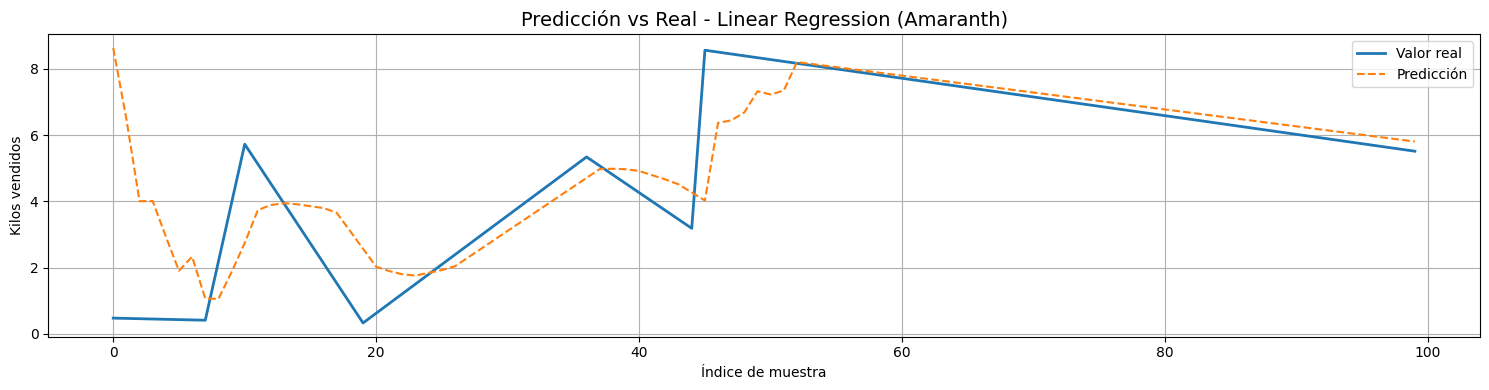


Random Forest
   MAE:  1.49
   RMSE: 2.44


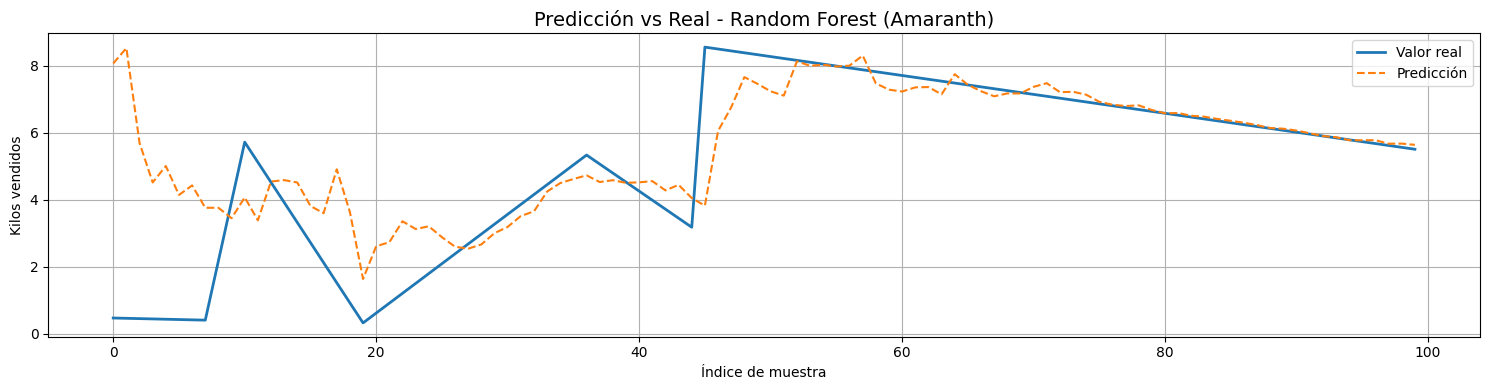


XGBoost
   MAE:  1.72
   RMSE: 2.72


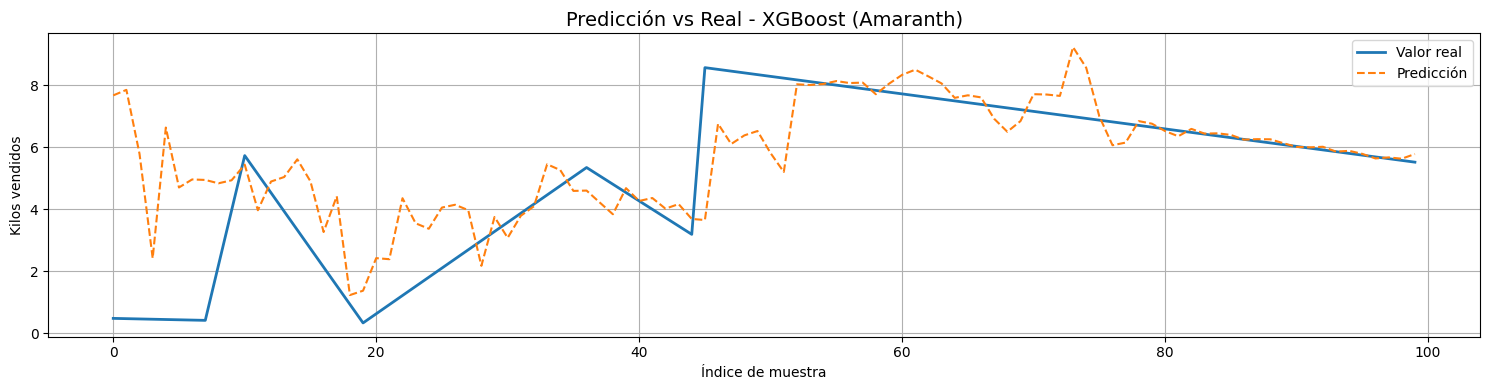

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('dataset_formateado.csv')

# Seleccionamos solo los registros de venta
df = df[df['Sale or Return'] == 'sale']

# Elegimos solo las columnas que nos interesan
df1 = df[['Item Name', 'Date', 'Quantity Sold (kilo)']]

# Convertimos la columna de la fecha en tipo DATE
df1['Date'] = pd.to_datetime(df1['Date'])

# Ordenamos por fecha
df1 = df1.sort_values(by='Date')

# Agrupamos la suma de kilogramos vendidos por nombre y fecha
df_grouped = df1.groupby(['Item Name', 'Date']).agg({'Quantity Sold (kilo)': 'sum'}).reset_index()
df_grouped.columns = ['Producto', 'Fecha', 'Kilos']


df_prod = df_grouped[df_grouped['Producto'] == producto_objetivo].copy()

# Verificar si el producto existe
if df_prod.empty:
    raise ValueError(f"No se encontraron datos para el producto: '{producto_objetivo}'")

# Crear rango de fechas completo para ese producto
fecha_inicio = df_prod['Fecha'].min()
fecha_fin = df_prod['Fecha'].max()
fechas_completas = pd.DataFrame({'Fecha': pd.date_range(fecha_inicio, fecha_fin, freq='D')})

# Merge con fechas completas
df_prod_full = fechas_completas.merge(df_prod, on='Fecha', how='left')
df_prod_full['Producto'] = producto_objetivo
df_prod_full['Kilos'] = df_prod_full['Kilos'].interpolate(method='linear', limit_direction='both')

# Trabajamos solo con este producto
df_filtrado = df_prod_full.copy()

# Parámetros de ventana y test
window_size = 7
test_ratio = 0.3
forecasting_horizon = 1

serie = df_filtrado['Kilos'].values

# División train/test
split_index = int(len(serie) * (1 - test_ratio))
serie_train = serie[:split_index]
serie_test = serie[split_index - window_size:]

X_train, y_train, X_test, y_test = [], [], [], []

# Entrenamiento
for i in range(len(serie_train) - window_size - forecasting_horizon + 1):
    X_train.append(serie_train[i:i+window_size])
    y_train.append(serie_train[i+window_size:i+window_size+forecasting_horizon])

# Test
for i in range(len(serie_test) - window_size - forecasting_horizon + 1):
    X_test.append(serie_test[i:i+window_size])
    y_test.append(serie_test[i+window_size:i+window_size+forecasting_horizon])

# Arrays finales
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

# Aplanar si horizonte = 1
if forecasting_horizon == 1:
    y_train = y_train.ravel()
    y_test = y_test.ravel()

# Modelos
modelos = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n{nombre}")
    print(f"   MAE:  {mae:.2f}")
    print(f"   RMSE: {rmse:.2f}")

    # Gráfico
    plt.figure(figsize=(15, 4))
    plt.plot(y_test[:100], label='Valor real', linewidth=2)
    plt.plot(y_pred[:100], label='Predicción', linestyle='--')
    plt.title(f'Predicción vs Real - {nombre} ({producto_objetivo})', fontsize=14)
    plt.xlabel('Índice de muestra')
    plt.ylabel('Kilos vendidos')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


#### Regresión Bivariada con Precio por Kg


Linear Regression
   MAE:  1.87
   RMSE: 3.04


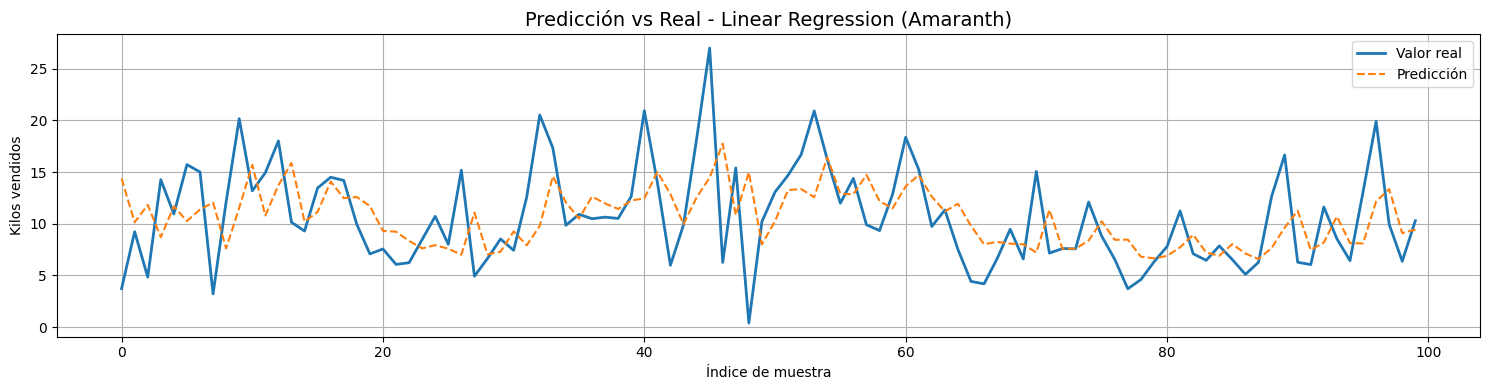


Random Forest
   MAE:  2.23
   RMSE: 3.37


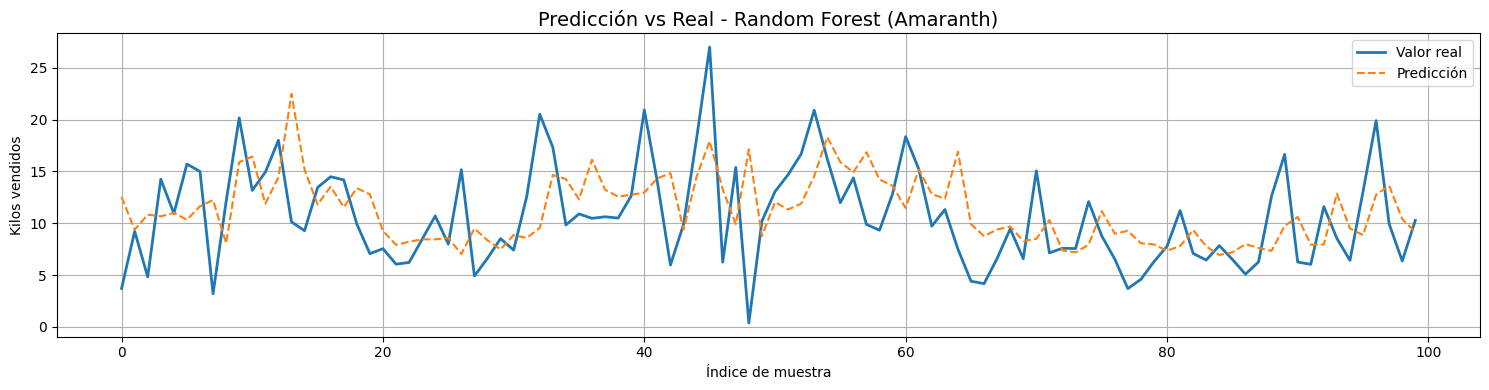


XGBoost
   MAE:  2.46
   RMSE: 3.60


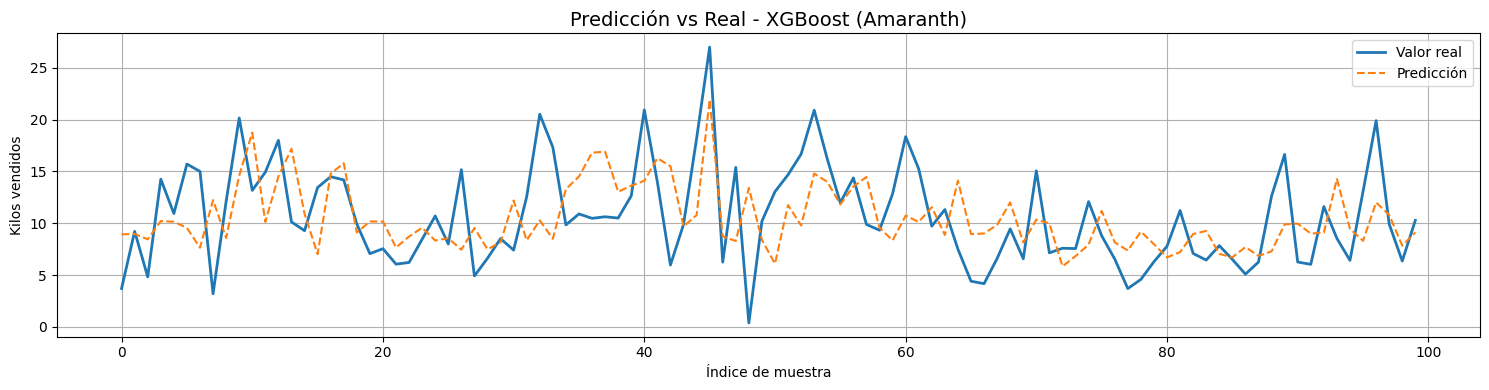

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. Cargar datos ---
df = pd.read_csv('dataset_formateado.csv')
df = df[df['Sale or Return'] == 'sale']

# Filtramos columnas relevantes
df = df[['Item Name', 'Date', 'Quantity Sold (kilo)', 'Unit Selling Price (EUR/kg)']]
df['Date'] = pd.to_datetime(df['Date'])

# Agrupamos por producto y fecha
df_grouped = df.groupby(['Item Name', 'Date']).agg({
    'Quantity Sold (kilo)': 'sum',
    'Unit Selling Price (EUR/kg)': 'mean'
}).reset_index()
df_grouped.columns = ['Producto', 'Fecha', 'Kilos', 'Precio']

# --- 2. Seleccionar producto específico ---


df_prod = df_grouped[df_grouped['Producto'] == producto_objetivo].copy()

if df_prod.empty:
    raise ValueError(f"No se encontraron datos para el producto: '{producto_objetivo}'")

# --- 3. Rellenar fechas e interpolar ---
fecha_inicio = df_prod['Fecha'].min()
fecha_fin = df_prod['Fecha'].max()
fechas_completas = pd.DataFrame({'Fecha': pd.date_range(fecha_inicio, fecha_fin)})
df_prod_full = fechas_completas.merge(df_prod, on='Fecha', how='left')
df_prod_full['Producto'] = producto_objetivo
df_prod_full['Kilos'] = df_prod_full['Kilos'].interpolate(method='linear', limit_direction='both')
df_prod_full['Precio'] = df_prod_full['Precio'].interpolate(method='linear', limit_direction='both')

# --- 4. Preparar datos para ventana deslizante ---
window_size = 7
forecasting_horizon = 1
test_ratio = 0.4

data = df_prod_full[['Kilos', 'Precio']].values
target = df_prod_full['Kilos'].values  # seguimos prediciendo solo Kilos

# División entre entrenamiento y test
split_index = int(len(data) * (1 - test_ratio))
data_train = data[:split_index]
data_test = data[split_index - window_size:]
target_test = target[split_index - window_size:]

X_train, y_train, X_test, y_test = [], [], [], []

# Entrenamiento
for i in range(len(data_train) - window_size - forecasting_horizon + 1):
    ventana = data_train[i:i+window_size]
    X_train.append(ventana.flatten())  # aplanamos la ventana
    y_train.append(target[i+window_size:i+window_size+forecasting_horizon])

# Test
for i in range(len(data_test) - window_size - forecasting_horizon + 1):
    ventana = data_test[i:i+window_size]
    X_test.append(ventana.flatten())
    y_test.append(target_test[i+window_size:i+window_size+forecasting_horizon])

# Convertir a arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

# Aplanar y_train/y_test si horizon=1
if forecasting_horizon == 1:
    y_train = y_train.ravel()
    y_test = y_test.ravel()

# --- 5. Entrenar y evaluar modelos ---
modelos = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n{nombre}")
    print(f"   MAE:  {mae:.2f}")
    print(f"   RMSE: {rmse:.2f}")

    # --- Gráfico ---
    plt.figure(figsize=(15, 4))
    plt.plot(y_test[:100], label='Valor real', linewidth=2)
    plt.plot(y_pred[:100], label='Predicción', linestyle='--')
    plt.title(f'Predicción vs Real - {nombre} ({producto_objetivo})', fontsize=14)
    plt.xlabel('Índice de muestra')
    plt.ylabel('Kilos vendidos')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Regresión Multivariante

C:\Users\santi\AppData\Local\Temp\ipykernel_7000\289138184.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date'] = pd.to_datetime(df1['Date'])



Linear Regression
   MAE:  1.82
   RMSE: 2.66


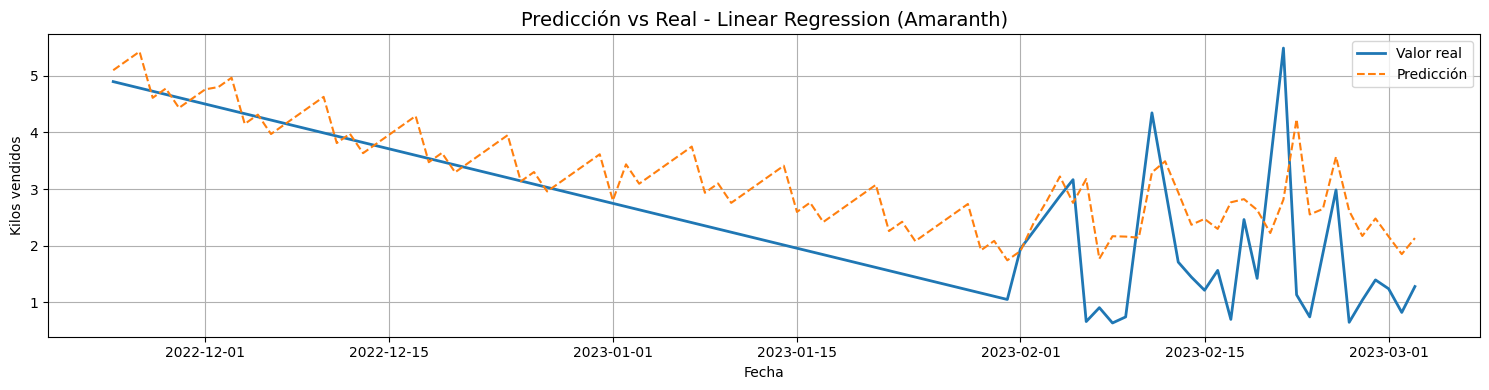


Random Forest
   MAE:  1.73
   RMSE: 2.70


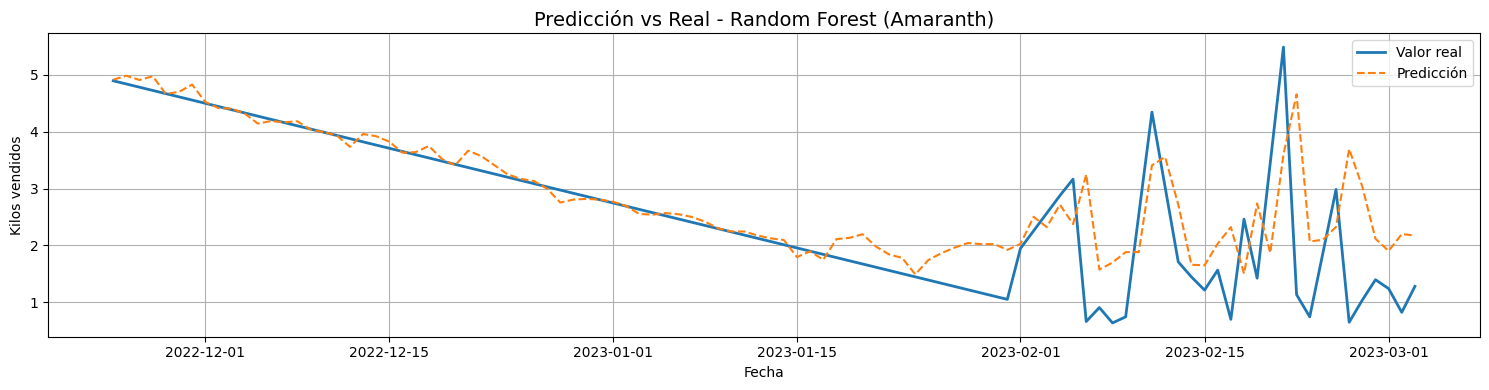


XGBoost
   MAE:  1.86
   RMSE: 2.99


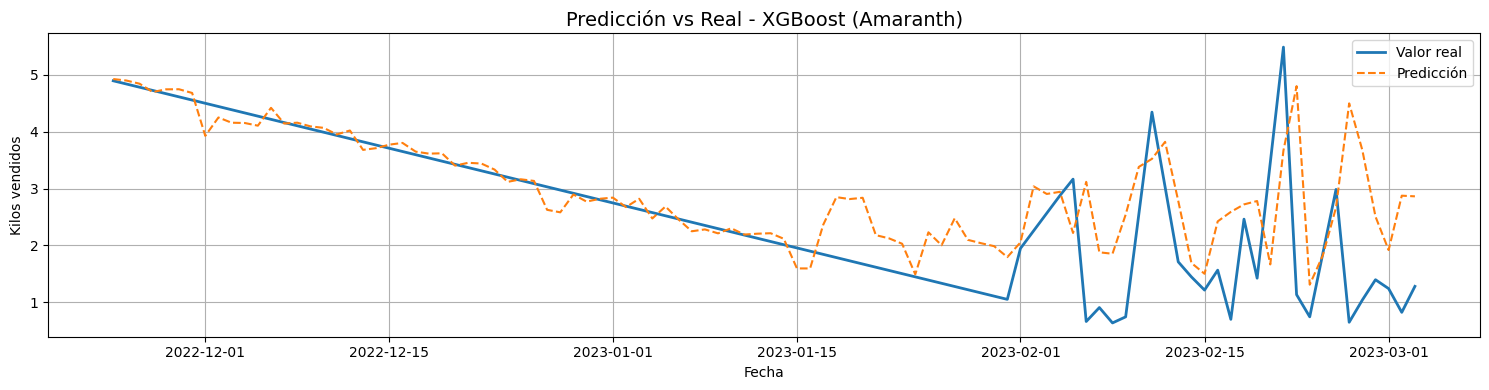

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. Cargar y preparar ---
df = pd.read_csv('dataset_formateado.csv')
df = df[df['Sale or Return'] == 'sale']
df1 = df[['Item Name', 'Date', 'Quantity Sold (kilo)']]
df1['Date'] = pd.to_datetime(df1['Date'])
df1 = df1.sort_values(by='Date')

df_grouped = df1.groupby(['Item Name', 'Date']).agg({'Quantity Sold (kilo)': 'sum'}).reset_index()
df_grouped.columns = ['Producto', 'Fecha', 'Kilos']

# Ver productos
# print("Productos disponibles:", df_grouped['Producto'].unique())

# --- 2. Seleccionar producto específico ---


df_prod = df_grouped[df_grouped['Producto'] == producto_objetivo].copy()

if df_prod.empty:
    raise ValueError(f"No se encontraron datos para el producto: '{producto_objetivo}'")

fecha_inicio = df_prod['Fecha'].min()
fecha_fin = df_prod['Fecha'].max()
fechas_completas = pd.DataFrame({'Fecha': pd.date_range(fecha_inicio, fecha_fin, freq='D')})
df_prod_full = fechas_completas.merge(df_prod, on='Fecha', how='left')
df_prod_full['Producto'] = producto_objetivo
df_prod_full['Kilos'] = df_prod_full['Kilos'].interpolate(method='linear', limit_direction='both')

# Extraer variables temporales
df_prod_full['dayofweek'] = df_prod_full['Fecha'].dt.dayofweek
df_prod_full['month'] = df_prod_full['Fecha'].dt.month
df_prod_full['dayofyear'] = df_prod_full['Fecha'].dt.dayofyear
df_prod_full['is_weekend'] = (df_prod_full['dayofweek'] >= 5).astype(int)

df_filtrado = df_prod_full.copy()

# --- 3. Preparar series ---
window_size = 7
forecasting_horizon = 1
test_ratio = 0.2

serie = df_filtrado['Kilos'].values
fechas = df_filtrado['Fecha'].values
features_temporales = df_filtrado[['dayofweek', 'month', 'dayofyear', 'is_weekend']].values

split_index = int(len(serie) * (1 - test_ratio))
serie_train = serie[:split_index]
serie_test = serie[split_index - window_size:]
fechas_test = fechas[split_index - window_size:]
features_test = features_temporales[split_index - window_size:]
features_train = features_temporales[:split_index]

X_train, y_train, X_test, y_test, fechas_y_test = [], [], [], [], []

# Entrenamiento
for i in range(len(serie_train) - window_size - forecasting_horizon + 1):
    ventana = serie_train[i:i+window_size].tolist()
    meta = features_train[i+window_size-1].tolist()
    X_train.append(ventana + meta)
    y_train.append(serie_train[i+window_size:i+window_size+forecasting_horizon])

# Test
for i in range(len(serie_test) - window_size - forecasting_horizon + 1):
    ventana = serie_test[i:i+window_size].tolist()
    meta = features_test[i+window_size-1].tolist()
    X_test.append(ventana + meta)
    y_test.append(serie_test[i+window_size:i+window_size+forecasting_horizon])
    fechas_y_test.append(fechas_test[i+window_size])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)
fechas_y_test = np.array(fechas_y_test)

if forecasting_horizon == 1:
    y_train = y_train.ravel()
    y_test = y_test.ravel()

# --- 4. Modelos ---
modelos = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n{nombre}")
    print(f"   MAE:  {mae:.2f}")
    print(f"   RMSE: {rmse:.2f}")

    # Gráfico
    plt.figure(figsize=(15, 4))
    plt.plot(fechas_y_test[:100], y_test[:100], label='Valor real', linewidth=2)
    plt.plot(fechas_y_test[:100], y_pred[:100], label='Predicción', linestyle='--')
    plt.title(f'Predicción vs Real - {nombre} ({producto_objetivo})', fontsize=14)
    plt.xlabel('Fecha')
    plt.ylabel('Kilos vendidos')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [6]:
df.head()

,Unnamed: 0,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (EUR/kg),Sale or Return,Discount (Yes/No),Item Name,Category Code,Category Name
0,0,2020-07-01,09:15:07,0,0.396,0.99,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum
1,1,2020-07-01,09:17:27,1,0.849,0.42,sale,No,Chinese Cabbage,1011010101,Flower/Leaf Vegetables
2,2,2020-07-01,09:17:33,0,0.409,0.99,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum
3,3,2020-07-01,09:19:45,2,0.421,1.30,sale,No,Shanghaiqing,1011010101,Flower/Leaf Vegetables
4,4,2020-07-01,09:20:23,3,0.539,1.04,sale,No,Caixin,1011010101,Flower/Leaf Vegetables


### MODELO LSTM

#### UNIVARIANTE

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# --- 1. Cargar y preparar datos ---
df = pd.read_csv('dataset_formateado.csv')
df = df[df['Sale or Return'] == 'sale']
df = df[['Item Name', 'Date', 'Quantity Sold (kilo)']]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

df_grouped = df.groupby(['Item Name', 'Date']).agg({'Quantity Sold (kilo)': 'sum'}).reset_index()
df_grouped.columns = ['Producto', 'Fecha', 'Kilos']

# --- 2. Seleccionar producto ---

df_prod = df_grouped[df_grouped['Producto'] == producto_objetivo].copy()

if df_prod.empty:
    raise ValueError(f"No se encontraron datos para el producto: '{producto_objetivo}'")

# Rellenar fechas e interpolar
fecha_inicio = df_prod['Fecha'].min()
fecha_fin = df_prod['Fecha'].max()
fechas_completas = pd.DataFrame({'Fecha': pd.date_range(fecha_inicio, fecha_fin)})
df_prod_full = fechas_completas.merge(df_prod, on='Fecha', how='left')
df_prod_full['Producto'] = producto_objetivo
df_prod_full['Kilos'] = df_prod_full['Kilos'].interpolate(method='linear', limit_direction='both')

# --- 3. Preparar datos para LSTM univariante ---
window_size = 7
forecasting_horizon = 1  # AHORA explícitamente parte del código
test_ratio = 0.3

serie = df_prod_full['Kilos'].values
fechas = df_prod_full['Fecha'].values

# Aseguramos que no falten valores para horizon al final
split_index = int(len(serie) * (1 - test_ratio))
serie_train = serie[:split_index]
serie_test = serie[split_index - window_size:]  # incluye ventana previa
fechas_test = fechas[split_index - window_size:]

X_train, y_train, X_test, y_test, fechas_y_test = [], [], [], [], []

# Train
for i in range(len(serie_train) - window_size - forecasting_horizon + 1):
    X_train.append(serie_train[i:i + window_size])
    y_train.append(serie_train[i + window_size:i + window_size + forecasting_horizon])

# Test
for i in range(len(serie_test) - window_size - forecasting_horizon + 1):
    X_test.append(serie_test[i:i + window_size])
    y_test.append(serie_test[i + window_size:i + window_size + forecasting_horizon])
    fechas_y_test.append(fechas_test[i + window_size:i + window_size + forecasting_horizon])

# Convertir a arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)
fechas_y_test = np.array(fechas_y_test)

# Aplanar si forecasting_horizon = 1
if forecasting_horizon == 1:
    y_train = y_train.ravel()
    y_test = y_test.ravel()
    fechas_y_test = fechas_y_test.ravel()

# --- 4. Redimensionar para LSTM ---
X_train_lstm = X_train.reshape((X_train.shape[0], window_size, 1))
X_test_lstm = X_test.reshape((X_test.shape[0], window_size, 1))

# --- 5. Modelo LSTM ---
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(window_size, 1)))
model.add(Dense(forecasting_horizon))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# --- 6. Predicción y evaluación ---
y_pred = model.predict(X_test_lstm)

# Evaluación
if forecasting_horizon == 1:
    y_pred = y_pred.ravel()
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
else:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nLSTM univariante - Horizon {forecasting_horizon} - MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# --- 7. Graficar ---
plt.figure(figsize=(15, 4))
plt.plot(fechas_y_test[:100], y_test[:100], label='Real', linewidth=2)
plt.plot(fechas_y_test[:100], y_pred[:100], label='Predicción', linestyle='--')
plt.title(f'Predicción t+{forecasting_horizon} con LSTM univariante ({producto_objetivo})')
plt.xlabel('Fecha')
plt.ylabel('Kilos vendidos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'tensorflow.keras'

#### Multivariante Características De Fecha

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# --- 1. Cargar datos ---
df = pd.read_csv('dataset_formateado.csv')
df = df[df['Sale or Return'] == 'sale']
df1 = df[['Item Name', 'Date', 'Quantity Sold (kilo)']]
df1['Date'] = pd.to_datetime(df1['Date'])
df1 = df1.sort_values(by='Date')

df_grouped = df1.groupby(['Item Name', 'Date']).agg({'Quantity Sold (kilo)': 'sum'}).reset_index()
df_grouped.columns = ['Producto', 'Fecha', 'Kilos']

# --- 2. Seleccionar producto ---

df_prod = df_grouped[df_grouped['Producto'] == producto_objetivo].copy()

if df_prod.empty:
    raise ValueError(f"No se encontraron datos para el producto: '{producto_objetivo}'")

# Rellenar fechas e interpolar
fecha_inicio = df_prod['Fecha'].min()
fecha_fin = df_prod['Fecha'].max()
fechas_completas = pd.DataFrame({'Fecha': pd.date_range(fecha_inicio, fecha_fin, freq='D')})
df_prod_full = fechas_completas.merge(df_prod, on='Fecha', how='left')
df_prod_full['Producto'] = producto_objetivo
df_prod_full['Kilos'] = df_prod_full['Kilos'].interpolate(method='linear', limit_direction='both')

# --- 3. Añadir variables temporales ---
df_prod_full['dayofweek'] = df_prod_full['Fecha'].dt.dayofweek
df_prod_full['month'] = df_prod_full['Fecha'].dt.month
df_prod_full['is_weekend'] = (df_prod_full['dayofweek'] >= 5).astype(int)

# --- 4. Preparar datos para LSTM ---
window_size = 7
forecasting_horizon = 1
test_ratio = 0.25

features = ['Kilos', 'dayofweek', 'month', 'is_weekend']
data = df_prod_full[features].values
fechas = df_prod_full['Fecha'].values

split_index = int(len(data) * (1 - test_ratio))
data_train = data[:split_index]
data_test = data[split_index - window_size:]
fechas_test = fechas[split_index - window_size:]

X_train, y_train, X_test, y_test, fechas_y_test = [], [], [], [], []

# Entrenamiento
for i in range(len(data_train) - window_size - forecasting_horizon + 1):
    X_train.append(data_train[i:i+window_size])
    y_train.append(data_train[i+window_size:i+window_size+forecasting_horizon, 0])  # solo Kilos

# Test
for i in range(len(data_test) - window_size - forecasting_horizon + 1):
    X_test.append(data_test[i:i+window_size])
    y_test.append(data_test[i+window_size:i+window_size+forecasting_horizon, 0])
    fechas_y_test.append(fechas_test[i+window_size:i+window_size+forecasting_horizon])

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)
fechas_y_test = np.array(fechas_y_test)

# --- 5. Construir y entrenar el modelo LSTM ---
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(window_size, X_train.shape[2])))
model.add(Dense(forecasting_horizon))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# --- 6. Predicción y evaluación ---
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nLSTM multivariante ({forecasting_horizon}-días) - MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# --- 7. Graficar solo el primer paso (t+1) ---
plt.figure(figsize=(15, 4))
plt.plot(fechas_y_test[:, 0][:100], y_test[:, 0][:100], label='Real (t+1)', linewidth=2)
plt.plot(fechas_y_test[:, 0][:100], y_pred[:, 0][:100], label='Predicción (t+1)', linestyle='--')
plt.title(f'Predicción horizonte {forecasting_horizon} con LSTM multivariante ({producto_objetivo})')
plt.xlabel('Fecha')
plt.ylabel('Kilos vendidos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Bivariado Con Precio por Kg

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# --- 1. Cargar y preparar datos ---
df = pd.read_csv('dataset_formateado.csv')
df = df[df['Sale or Return'] == 'sale']
df = df[['Item Name', 'Date', 'Quantity Sold (kilo)', 'Unit Selling Price (EUR/kg)']]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

df.columns = ['Producto', 'Fecha', 'Kilos', 'Precio']
df_grouped = df.groupby(['Producto', 'Fecha']).agg({
    'Kilos': 'sum',
    'Precio': 'mean'
}).reset_index()

# --- 2. Seleccionar producto ---

df_prod = df_grouped[df_grouped['Producto'] == producto_objetivo].copy()

if df_prod.empty:
    raise ValueError(f"No se encontraron datos para el producto: '{producto_objetivo}'")

# Rellenar fechas e interpolar
fecha_inicio = df_prod['Fecha'].min()
fecha_fin = df_prod['Fecha'].max()
fechas_completas = pd.DataFrame({'Fecha': pd.date_range(fecha_inicio, fecha_fin)})
df_prod_full = fechas_completas.merge(df_prod, on='Fecha', how='left')
df_prod_full['Producto'] = producto_objetivo
df_prod_full['Kilos'] = df_prod_full['Kilos'].interpolate(method='linear', limit_direction='both')
df_prod_full['Precio'] = df_prod_full['Precio'].interpolate(method='linear', limit_direction='both')

# --- 3. Parámetros ---
window_size = 7
forecasting_horizon = 1
test_ratio = 0.3

# --- 4. Crear ventanas con horizon ---
data = df_prod_full[['Kilos', 'Precio']].values
target = df_prod_full['Kilos'].values
fechas = df_prod_full['Fecha'].values

split_index = int(len(data) * (1 - test_ratio))
data_train = data[:split_index]
data_test = data[split_index - window_size:]
target_test = target[split_index - window_size:]
fechas_test = fechas[split_index - window_size:]

X_train, y_train, X_test, y_test, fechas_y_test = [], [], [], [], []

for i in range(len(data_train) - window_size - forecasting_horizon + 1):
    X_train.append(data_train[i:i+window_size])
    y_train.append(target[i+window_size : i+window_size+forecasting_horizon])

for i in range(len(data_test) - window_size - forecasting_horizon + 1):
    X_test.append(data_test[i:i+window_size])
    y_test.append(target_test[i+window_size : i+window_size+forecasting_horizon])
    fechas_y_test.append(fechas_test[i+window_size : i+window_size+forecasting_horizon])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)
fechas_y_test = np.array(fechas_y_test)

# --- 5. Redimensionar para LSTM ---
X_train_lstm = X_train.reshape((X_train.shape[0], window_size, 2))
X_test_lstm = X_test.reshape((X_test.shape[0], window_size, 2))

# --- 6. Modelo LSTM multistep ---
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(window_size, 2)))
model.add(Dense(forecasting_horizon))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# --- 7. Predicción y evaluación ---
y_pred = model.predict(X_test_lstm)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


# --- 8. Gráficos por paso ---
for paso in range(forecasting_horizon):
    print(f"\nLSTM bivariado con horizonte {forecasting_horizon} - MAE: {mae:.2f} | RMSE: {rmse:.2f}")
    plt.figure(figsize=(15, 4))
    plt.plot(fechas_y_test[:, paso][:100], y_test[:, paso][:100], label=f'Real (t+{paso+1})', linewidth=2)
    plt.plot(fechas_y_test[:, paso][:100], y_pred[:, paso][:100], label=f'Predicción (t+{paso+1})', linestyle='--')
    plt.title(f'LSTM bivariado - t+{paso+1} ({producto_objetivo})')
    plt.xlabel('Fecha')
    plt.ylabel('Kilos vendidos')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
